# NWS damage survey photos

NWS damage surveyors photograph what they rate, and the Damage Assessment
Toolkit keeps each photo as an attachment of its damage point. One asset is one
photo, a JPEG or PNG exactly as stored, with its size known before download and
its point's id, position, storm time, and EF rating recorded beside it.

This walkthrough fetches the photos of EF5 damage points in a few blocks of
Phil Campbell, Alabama, struck by the Hackleburg-Phil Campbell tornado on
27 April 2011, and shows six of them. It needs matplotlib; the 36 files are
about 3 MB and the run takes under a minute.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-29T23:45:18+00:00
usdata 0.33.0; pandas 3.0.6


## Select

The query selects damage points, and the photos come with them: points whose
storm time falls in the window, inside the box, rated EF5. Windows may span at
most seven days, because listing asks for every matching point's attachments,
a hundred points at a time. The window covers whole UTC days: points surveyed
in 2011 often record only their date, stamped at 00:00 UTC. `as_of` reads the
service as it stood at that instant, so the listing cannot drift.

In [2]:
print(manifest.read_text())

name: phil-campbell-ef5-photos
sources:
  - name: photos
    dataset: noaa:nws-damage-photos
    # EF5 damage points in a few blocks of Phil Campbell, Alabama, on 27 April 2011.
    # Points of that year often carry only their date, stamped 00:00 UTC.
    start: 2011-04-27
    end: 2011-04-28
    bbox: {west: -87.740, south: 34.326, east: -87.734, north: 34.330}
    params: {efscale: EF5, as_of: "2026-09-29T00:00Z"}



## What arrives

One file per attachment, named by its point and attachment ids. Each asset's
`properties` hold what the JPEG does not say: which point it belongs to, the
point's rating, and the name it was uploaded under.

In [3]:
result = pull(manifest)
items = result.by_source["photos"]
print(f"{len(items)} files, {sum(i.provenance.size for i in items):,} bytes")
first = items[0]
print("File:", first.path.name)
print("Source:", first.provenance.source_url)
print("Checksum:", first.provenance.checksum)
print("Properties:", first.asset.properties)
print("Storm time:", first.asset.time.start, "at", (first.asset.bbox.west, first.asset.bbox.south))

36 files, 3,012,353 bytes
File: nws_damage_photo_25520_15668.jpg
Source: https://services.dat.noaa.gov/arcgis/rest/services/nws_damageassessmenttoolkit/DamageViewer/FeatureServer/0/25520/attachments/15668
Checksum: sha256:985797bac482a0f464b018c91db7d23577c18129204f15652f1a3c17cd44c4bf
Properties: {'point_objectid': '25520', 'name': '20110501_160432_IMG_0342.JPG', 'point_globalid': '{2E9D74E1-E538-4310-B1A2-BECECD0AFB8A}', 'efscale': 'EF5'}
Storm time: 2011-04-27 00:00:00+00:00 at (-87.73616666700002, 34.32850000000002)


## Open

No reader is bundled for images; matplotlib's `imread` opens a JPEG. First,
the listing itself: every point here holds two files of the same name, one
about twenty times the size of the other. The small one is a thumbnail the
toolkit made of each photo, 192 pixels wide. The service lists both and so does
usdata, since no rule separates them reliably across the archive; here the
larger of each pair is the photo.

In [4]:
listing = pd.DataFrame(
    {
        "file": item.path.name,
        "point": item.asset.properties["point_objectid"],
        "name": item.asset.properties["name"],
        "bytes": item.provenance.size,
        "path": item.path,
    }
    for item in items
)
listing["copy"] = listing.groupby(["point", "name"])["bytes"].rank(ascending=False)
photos = listing[listing["copy"] == 1].reset_index(drop=True)
thumbs = listing[listing["copy"] > 1]
print(f"{len(photos)} photos and {len(thumbs)} thumbnails on {listing['point'].nunique()} points")
print("Photo bytes:", photos["bytes"].describe()[["min", "50%", "max"]].to_dict())
print("Thumbnail bytes:", thumbs["bytes"].describe()[["min", "50%", "max"]].to_dict())
for label, row in (("photo", photos.iloc[0]), ("thumbnail", thumbs.iloc[0])):
    height, width = mpimg.imread(row["path"]).shape[:2]
    print(f"{label}: {row['file']} is {width} x {height} pixels")

18 photos and 18 thumbnails on 18 points
Photo bytes: {'min': 97303.0, '50%': 166973.5, 'max': 207784.0}
Thumbnail bytes: {'min': 4550.0, '50%': 7053.0, 'max': 9092.0}
photo: nws_damage_photo_25520_15668.jpg is 1024 x 765 pixels
thumbnail: nws_damage_photo_25520_20831.jpg is 192 x 143 pixels


## A first look

Six of the photos, each titled with its point and the start of its file name.

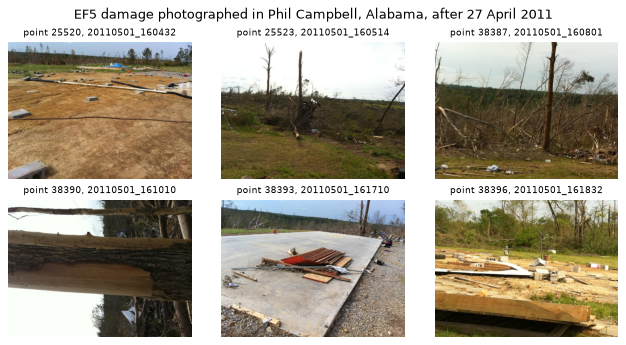

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(8, 4.2), dpi=80, layout="constrained")
for ax, (_, row) in zip(axes.flat, photos.iloc[::3].head(6).iterrows(), strict=True):
    ax.imshow(mpimg.imread(row["path"]))
    ax.set_title(f"point {row['point']}, {row['name'][:15]}", fontsize=8)
    ax.axis("off")
fig.suptitle("EF5 damage photographed in Phil Campbell, Alabama, after 27 April 2011")
plt.show()

The file names of this era begin with the time the point was surveyed, which
is the point's `surveydate` in `noaa:nws-damage-surveys`: `20110501_160432` is
1 May at 16:04, four days after the tornado. The asset's time is the storm's,
not the photo's.

## Pin and cite

`verify` checks every cached photo against the lockfile. The photos keep their
bytes once uploaded, and `as_of` keeps the listing itself fixed, so a restore
brings back the same files.

In [6]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:nws-damage-photos
  NOAA National Weather Service, Damage Assessment Toolkit (DamageViewer feature service) damage point photographs, accessed via usdata
  homepage: https://apps.dat.noaa.gov/StormDamage/DamageViewer/
  license: Public domain as NWS information; third-party images are used under their providers' licenses
  terms: https://www.weather.gov/disclaimer
  retrieved: 2026-09-29; 36 checksummed assets (3,012,353 bytes) pinned by usdata 0.33.0
  sources: photos


## What was awkward

- Thumbnails arrive beside the photos they copy. Before 2017 many points hold
  a small copy under the same name or a `thumb_` prefix, and a query cannot
  leave them out; the size tells them apart, and one line of pandas drops them.
- `imread` ignores the orientation a camera records in EXIF, so point 38390's
  photo, whose EXIF says it is rotated, shows on its side; Pillow's
  `ImageOps.exif_transpose` turns it upright. The thumbnails carry no EXIF.
- The time that matters for a photo is not stated anywhere reliable. The
  point's storm time here is a date at 00:00 UTC, the survey time is only in
  the file name or in the surveys layer, and the time the photo was taken only
  in its EXIF, when the camera wrote one.
- Photos are large. These are small older files; the 38 from one Oklahoma
  office on the night of 6 May 2024 are 226 MB, so a `--dry-run` before a
  fetch is worth the few seconds.
- A photo's rating and position are its point's. Anything else about the
  point, its damage indicator or comments, needs `noaa:nws-damage-surveys` and a
  join on `point_objectid`.